In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings


warnings.filterwarnings("ignore")
sns.set(style = 'whitegrid')

In [4]:
df = pd.read_csv('AIML Dataset (1).csv')


In [7]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:

print(df['isFraud'].value_counts())
print (df['isFlaggedFraud'].value_counts())



0    6354407
1       8213
Name: isFraud, dtype: int64
0    6362604
1         16
Name: isFlaggedFraud, dtype: int64


In [15]:
print( df.columns.isnull().sum())

0


In [17]:
df.shape

(6362620, 11)

In [34]:
print ('There is a ',((df['isFraud'].value_counts()[1])/ (df.shape[0]))*100 ,'percent of fraud in this dataset')

There is a  0.12908204481801522 percent of fraud in this dataset


Text(0, 0.5, 'count')

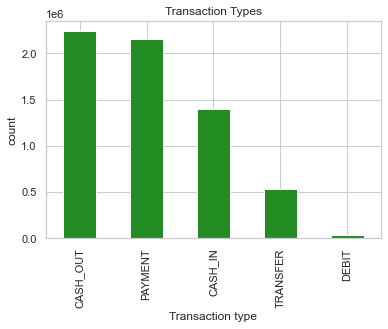

In [26]:
df['type'].value_counts().plot(kind  = 'bar', title= 'Transaction Types', color = 'forestgreen')
plt.xlabel('Transaction type')
plt.ylabel('count')

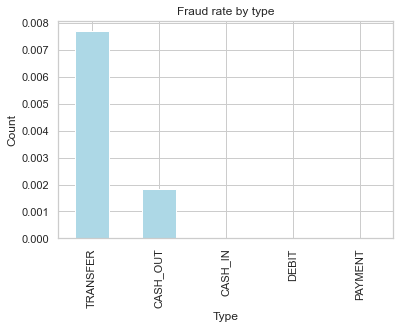

In [29]:
fraud_type = df.groupby('type')['isFraud'].mean().sort_values(ascending = False)
fraud_type.plot(kind = 'bar', title = 'Fraud rate by type', color = 'lightblue')
plt.ylabel('Fraud percent')
plt.xlabel('Type')
plt.show()s


In [35]:
fraud_type


type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [37]:
df['amount'].describe().astype(int)


count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

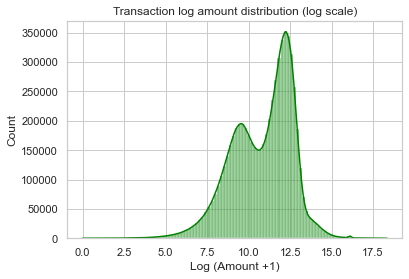

In [48]:
sns.histplot(np.log1p(df['amount']), bins = 100, kde = True, color = 'green')
plt.title('Transaction log amount distribution (log scale)')
plt.xlabel('Log (Amount +1)')
plt.show()

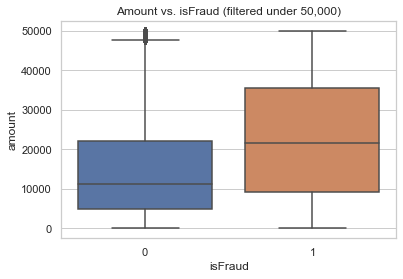

In [50]:
sns.boxplot(data = df[df['amount'] < 50000], x = 'isFraud', y = 'amount')
plt.title('Amount vs. isFraud (filtered under 50,000)')
plt.show()

In [55]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [56]:
(df['balanceDiffOrig']< 0).sum()

1399253

In [57]:
(df['balanceDiffDest']< 0).sum()

1238864

In [58]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


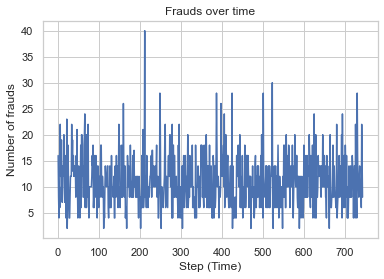

In [61]:
fraud_step = df[df['isFraud']== 1]['step'].value_counts().sort_index()
plt.plot(fraud_step.index, fraud_step.values, label = 'Frauds per step')
plt.xlabel('Step (Time)')
plt.ylabel('Number of frauds')
plt.title('Frauds over time')
plt.grid(True)
plt.show()

In [62]:
df.drop(columns= 'step', inplace = True)

In [63]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [69]:
top_sender = df['nameOrig'].value_counts().head()
top_sender



C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
Name: nameOrig, dtype: int64

In [70]:
top_receiver = df['nameDest'].value_counts().head

In [72]:
fraud_user = df[df['isFraud']== 1]['nameOrig'].value_counts().head()
fraud_user

C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
Name: nameOrig, dtype: int64

In [78]:
fraud_type = df[df ['type'].isin(['TRANSFER', 'CASH_OUT'])]
fraud_type['type'].value_counts()

CASH_OUT    2237500
TRANSFER     532909
Name: type, dtype: int64

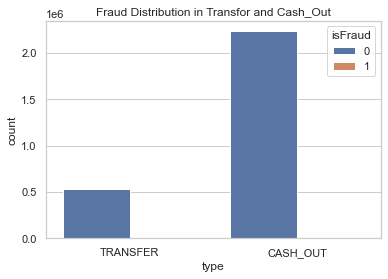

In [79]:

sns.countplot(data = fraud_type, x = 'type', hue = 'isFraud')
plt.title('Fraud Distribution in Transfor and Cash_Out')
plt.show()

In [83]:
corr = df[['amount' ,'oldbalanceOrg','newbalanceOrig','oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


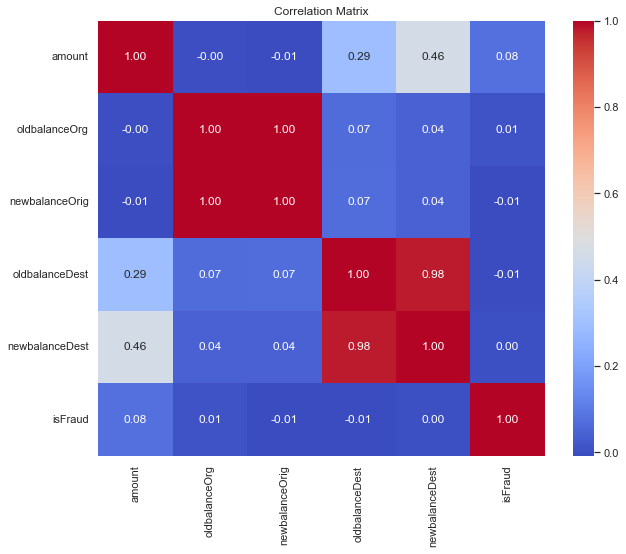

In [88]:

plt.figure(figsize= (10, 8))
sns.heatmap(data  = corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()

In [90]:
zero_after_transfer = df[
    (df['oldbalanceOrg']> 0)&
    (df['newbalanceOrig'] == 0 )& 
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]

In [93]:
len(zero_after_transfer)



1188074

In [94]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [95]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [99]:
df_model  = df.drop(['nameOrig','nameDest', 'isFlaggedFraud'], axis = 1 )

In [113]:
categorical =['type']
numeric = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


In [114]:
y = df_model['isFraud']
X = df_model.drop('isFraud', axis = 1)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.3, stratify= y )

In [116]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric), 
        ('cat', OneHotEncoder(drop = 'first'), categorical) 
    ], 
    remainder = 'drop'
)

In [117]:
pipeline = Pipeline ([
    ('prep', preprocessor), 
    ('clf', LogisticRegression(class_weight= 'balanced', max_iter  = 1000))
])

In [118]:
pipeline.fit(X_train, y_train )

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [119]:
y_pred = pipeline.predict(X_test)


In [120]:
print ( classification_report(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.93      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [121]:
confusion_matrix (y_test, y_pred)

array([[1806563,   99759],
       [    171,    2293]])

In [123]:
pipeline.score(X_test, y_test)*100

94.76473528200647

In [126]:
import joblib
joblib.dump(pipeline, 'fraud_detection_pipeline.pkl')

['fraud_detection_pipeline.pkl']